<a href="https://colab.research.google.com/github/sarans2223/NAIVE_BAYES-ML/blob/main/Naive_basis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Download latest version
path = kagglehub.dataset_download(
    "waqi786/usa-rainfall-prediction-dataset-2024-2025"
)

print("Path to dataset files:", path)

100%|██████████| 3.90M/3.90M [00:01<00:00, 3.95MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/waqi786/usa-rainfall-prediction-dataset-2024-2025/versions/1


In [ ]:
import os

print(os.listdir(path))

['usa_rain_prediction_dataset_2024_2025.csv']


In [ ]:
df = pd.read_csv(
    os.path.join(path, "usa_rain_prediction_dataset_2024_2025.csv")
)

df.head()

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0


In [ ]:
df = df.rename(columns={'Rain Tomorrow': 'rain_tomorrow'})
display(df.head())

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,rain_tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0


In [ ]:
print("Shape:", df.shape)

Shape: (73100, 9)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           73100 non-null  object 
 1   Location       73100 non-null  object 
 2   Temperature    73100 non-null  float64
 3   Humidity       73100 non-null  float64
 4   Wind Speed     73100 non-null  float64
 5   Precipitation  73100 non-null  float64
 6   Cloud Cover    73100 non-null  float64
 7   Pressure       73100 non-null  float64
 8   rain_tomorrow  73100 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 5.0+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation,0
Cloud Cover,0
Pressure,0
rain_tomorrow,0


In [ ]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,rain_tomorrow
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,65.182270,59.875041,15.017946,0.390635,54.942807,1005.176013,0.220410
std,20.205793,23.066115,8.668729,0.474833,25.982487,20.203889,0.414526
min,30.000766,20.000272,0.000712,0.000000,10.000856,970.000919,0.000000
25%,47.678968,39.800732,7.485182,0.000000,32.318668,987.697646,0.000000
50%,65.294949,59.887840,15.102495,0.196909,55.011121,1005.284188,0.000000
75%,82.636570,79.835990,22.551794,0.673177,77.412469,1022.727410,0.000000
max,99.997393,99.999025,29.999017,3.078090,99.998957,1039.999765,1.000000


In [ ]:
df['rain_tomorrow'].value_counts()

,count
rain_tomorrow,
0,56988
1,16112


In [ ]:
df['rain_tomorrow'].value_counts()

,count
rain_tomorrow,
0,56988
1,16112


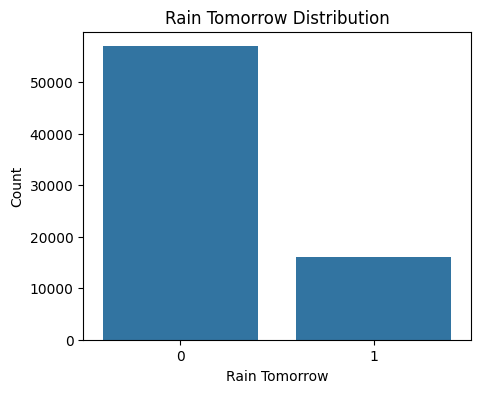

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x="rain_tomorrow", data=df)

plt.title("Rain Tomorrow Distribution")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Count")
plt.show()

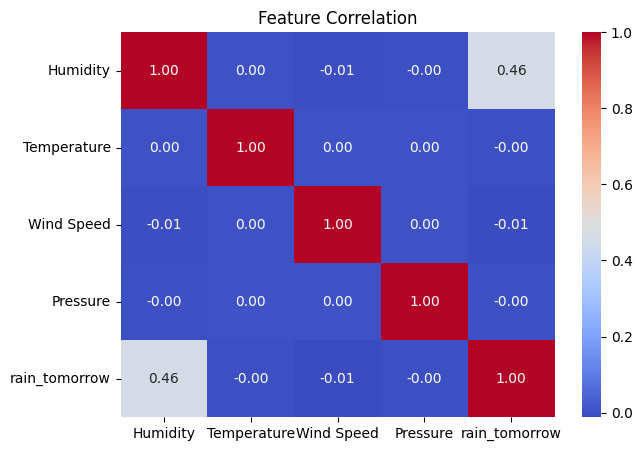

In [ ]:
features = ["Humidity", "Temperature", "Wind Speed", "Pressure"]
target = "rain_tomorrow"

X = df[features]
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7534199726402189
Accuracy (%): 75.34199726402188


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84     11398
           1       0.45      0.51      0.48      3222

    accuracy                           0.75     14620
   macro avg       0.65      0.67      0.66     14620
weighted avg       0.77      0.75      0.76     14620



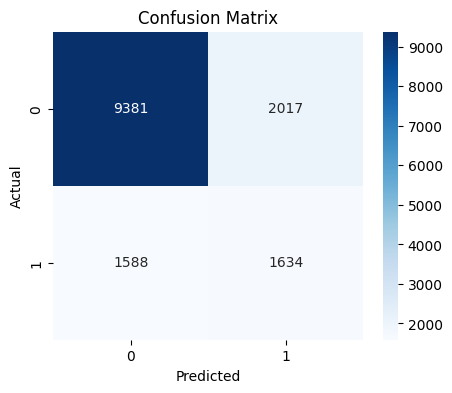

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
new_weather = pd.DataFrame({
    "Humidity": [75.0],
    "Temperature": [28.0],
    "Wind Speed": [12.0],
    "Pressure": [1010.0]
})

prediction = model.predict(new_weather)
print("Prediction:", prediction[0])

Prediction: 0


In [ ]:
if prediction[0] == 1:
    print("🌧️ It is predicted to rain tomorrow.")
else:
    print("☀️ It is predicted not to rain tomorrow.")

☀️ It is predicted not to rain tomorrow.


In [ ]:
probability = model.predict_proba(new_weather)
print("Probability of No Rain:", probability[0][0])
print("Probability of Rain:", probability[0][1])

Probability of No Rain: 0.5591078108995824
Probability of Rain: 0.44089218910041705
